# ChIP CPM profiles at RAD21 peaks - Figure 1E

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import bioframe as bf
import bbi
from functools import partial
from tqdm.contrib.concurrent import process_map

In [4]:
plt.rcParams.update({'pdf.fonttype': 42,
                     'ps.fonttype': 42})
sns.set_context('talk')

## Load data

### Peaks

In [5]:
rad21_peaks = bf.read_table('/groups/gerlich/labinfo/Papers/2025_ReplChromConf/analysis/assets/reproducible_peaks/RAD21_WT_G2.reprod_peaks.narrowPeak', schema='narrowPeak')
rad21_peaks = rad21_peaks.query('chrom != "chrY"').reset_index(drop=True)

### ChIP-Seq signal

In [6]:
chip_cpm = {'Sororin': '/groups/gerlich/experiments/Experiments_006500/006575/bam_repo/Sororin/WT_G2/Sororin_WT_G2.chip.bw',
            'RAD21': '/groups/gerlich/experiments/Experiments_006500/006575/bam_repo/RAD21/WT_G2/RAD21_WT_G2.chip.bw'}

### Copy number variations

In [7]:
cn_path = '/groups/gerlich/labinfo/Papers/2025_ReplChromConf/analysis/assets/copy_numbers/cnv_seg.bw'

## Extract chip-seq signal

In [8]:
def _extract_signal_chunk(df, path, bins=-1, summary='mean', missing=np.nan, cols=None):
    chrom_col, start_col, end_col = 'chrom', 'start', 'end'
    if cols is not None:
        if len(cols) == 3:
            chrom_col, start_col, end_col = cols
    with bbi.open(path) as f:
        hmap = f.stackup(df[chrom_col], df[start_col], df[end_col], bins=bins, summary=summary, missing=missing)
    return hmap


def extract_signal(df, path, bins=-1, summary='mean', missing=np.nan, chunks=1, cores=1, cols=None):
    df_chuncks = np.array_split(df, chunks)
    func = partial(_extract_signal_chunk, path=path, bins=bins, summary=summary, missing=missing, cols=cols)
    results = process_map(func, df_chuncks, max_workers=cores, desc='chunk')
    return np.concatenate(results)

def assign_signals(df):
    cn_data = extract_signal(df, cn_path, bins=1, chunks=100, cores=8)
    for prot, path in chip_cpm.items():
        signal_data = extract_signal(df, path, bins=1, chunks=100, cores=8)
        norm_data = signal_data / cn_data
        norm_data[np.isinf(norm_data)] = np.nan
        df[f"{prot}_cpm"] = norm_data
        df[f"{prot}_logcpm"] = np.log2(norm_data)

In [10]:
assign_signals(rad21_peaks)

chunk:   0%|          | 0/100 [00:00<?, ?it/s]

chunk:   0%|          | 0/100 [00:00<?, ?it/s]

chunk:   0%|          | 0/100 [00:00<?, ?it/s]

In [11]:
rad21_peaks

,chrom,start,end,name,score,strand,fc,-log10p,-log10q,relSummit,Sororin_cpm,Sororin_logcpm,RAD21_cpm,RAD21_logcpm
0,chr1,805114,805515,chip_peak_7,246,.,2.06626,26.7406,24.6003,221,0.211620,-2.240452,0.460216,-1.119615
1,chr1,919477,919993,chip_peak_11,1656,.,6.33545,168.4880,165.6530,259,0.128700,-2.957912,0.577406,-0.792342
2,chr1,937237,937521,chip_peak_12,104,.,1.65389,12.4361,10.4883,128,0.078327,-3.674351,0.472772,-1.080785
3,chr1,950759,951143,chip_peak_13,569,.,3.16500,59.3294,56.9572,193,0.081774,-3.612206,0.466003,-1.101588
4,chr1,999134,999542,chip_peak_15,595,.,2.78718,61.9548,59.5668,201,0.355585,-1.491734,0.614796,-0.701821
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59996,chrX,154407661,154408288,chip_peak_129776,1801,.,12.91240,183.0370,180.1460,396,0.212813,-2.232342,0.315623,-1.663725
59997,chrX,154445000,154445718,chip_peak_129777,258,.,2.64946,27.9632,25.8108,160,0.176846,-2.499432,0.253169,-1.981825
59998,chrX,154764426,154764928,chip_peak_129780,979,.,8.85916,100.4700,97.9012,226,0.025818,-5.275468,0.241149,-2.052006
59999,chrX,154880773,154881312,chip_peak_129781,790,.,7.85835,81.5647,79.0780,297,0.066505,-3.910403,0.222930,-2.165338


## Calculate Sororin/RAD21 ratio

In [12]:
rad21_peaks['Sor_RAD21_CPM_ratio'] = rad21_peaks['Sororin_cpm'] / rad21_peaks['RAD21_cpm']

In [13]:
rad21_peaks

,chrom,start,end,name,score,strand,fc,-log10p,-log10q,relSummit,Sororin_cpm,Sororin_logcpm,RAD21_cpm,RAD21_logcpm,Sor_RAD21_CPM_ratio
0,chr1,805114,805515,chip_peak_7,246,.,2.06626,26.7406,24.6003,221,0.211620,-2.240452,0.460216,-1.119615,0.459827
1,chr1,919477,919993,chip_peak_11,1656,.,6.33545,168.4880,165.6530,259,0.128700,-2.957912,0.577406,-0.792342,0.222894
2,chr1,937237,937521,chip_peak_12,104,.,1.65389,12.4361,10.4883,128,0.078327,-3.674351,0.472772,-1.080785,0.165676
3,chr1,950759,951143,chip_peak_13,569,.,3.16500,59.3294,56.9572,193,0.081774,-3.612206,0.466003,-1.101588,0.175480
4,chr1,999134,999542,chip_peak_15,595,.,2.78718,61.9548,59.5668,201,0.355585,-1.491734,0.614796,-0.701821,0.578379
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59996,chrX,154407661,154408288,chip_peak_129776,1801,.,12.91240,183.0370,180.1460,396,0.212813,-2.232342,0.315623,-1.663725,0.674263
59997,chrX,154445000,154445718,chip_peak_129777,258,.,2.64946,27.9632,25.8108,160,0.176846,-2.499432,0.253169,-1.981825,0.698529
59998,chrX,154764426,154764928,chip_peak_129780,979,.,8.85916,100.4700,97.9012,226,0.025818,-5.275468,0.241149,-2.052006,0.107063
59999,chrX,154880773,154881312,chip_peak_129781,790,.,7.85835,81.5647,79.0780,297,0.066505,-3.910403,0.222930,-2.165338,0.298320


## Plot ChIP-Seq stacked lines using +/- 1 kb windows centered at RAD21 peaks

### Set parameters
- +/- 1kb window
- 50 bp binsize

In [14]:
BINSIZE = 50
PAD = 1_000
BINS = (2 * PAD) // BINSIZE + 1

### Define path to ChIP-Seq signals

In [15]:
track_paths = {'RAD21_G2': '/groups/gerlich/experiments/Experiments_006500/006575/bam_repo/RAD21/WT_G2/RAD21_WT_G2.chip.bw',
               'Sororin': '/groups/gerlich/experiments/Experiments_006500/006575/bam_repo/Sororin/WT_G2/Sororin_WT_G2.chip.bw',
               'CTCF': '/groups/gerlich/experiments/Experiments_006500/006575/bam_repo/CTCF/WT_G2/CTCF_WT_G2.chip.bw'}

### Make windows

In [16]:
midpoints = (rad21_peaks['start'] + rad21_peaks['end']) // 2

In [17]:
windows = pd.DataFrame({'chrom': rad21_peaks['chrom'],
                        'start': midpoints - PAD,
                        'end': midpoints + PAD})

In [18]:
copy_numbers_hmap = extract_signal(windows, cn_path, bins=BINS, missing=np.nan, chunks=100, cores=8)
copy_numbers_hmap[copy_numbers_hmap == 0] = np.nan

chunk:   0%|          | 0/100 [00:00<?, ?it/s]

In [19]:
heatmaps = dict()
for track_name, track_path in track_paths.items():
    signal = extract_signal(windows, track_path, bins=BINS, missing=np.nan, chunks=100, cores=8)
    signal = signal / copy_numbers_hmap
    heatmaps[track_name] = signal

chunk:   0%|          | 0/100 [00:00<?, ?it/s]

chunk:   0%|          | 0/100 [00:00<?, ?it/s]

chunk:   0%|          | 0/100 [00:00<?, ?it/s]

### Plot stacked-line of ChIP-Seq signals

In [20]:
protein_settings = {
    'RAD21_G2': {'vmin': 0, 'vmax': 0.5, 'cmap': 'Blues'},
    'Sororin': {'vmin': 0, 'vmax': 0.4, 'cmap': 'Reds'},
    'CTCF': {'vmin': 0, 'vmax': 0.8, 'cmap': 'Greens'}
}

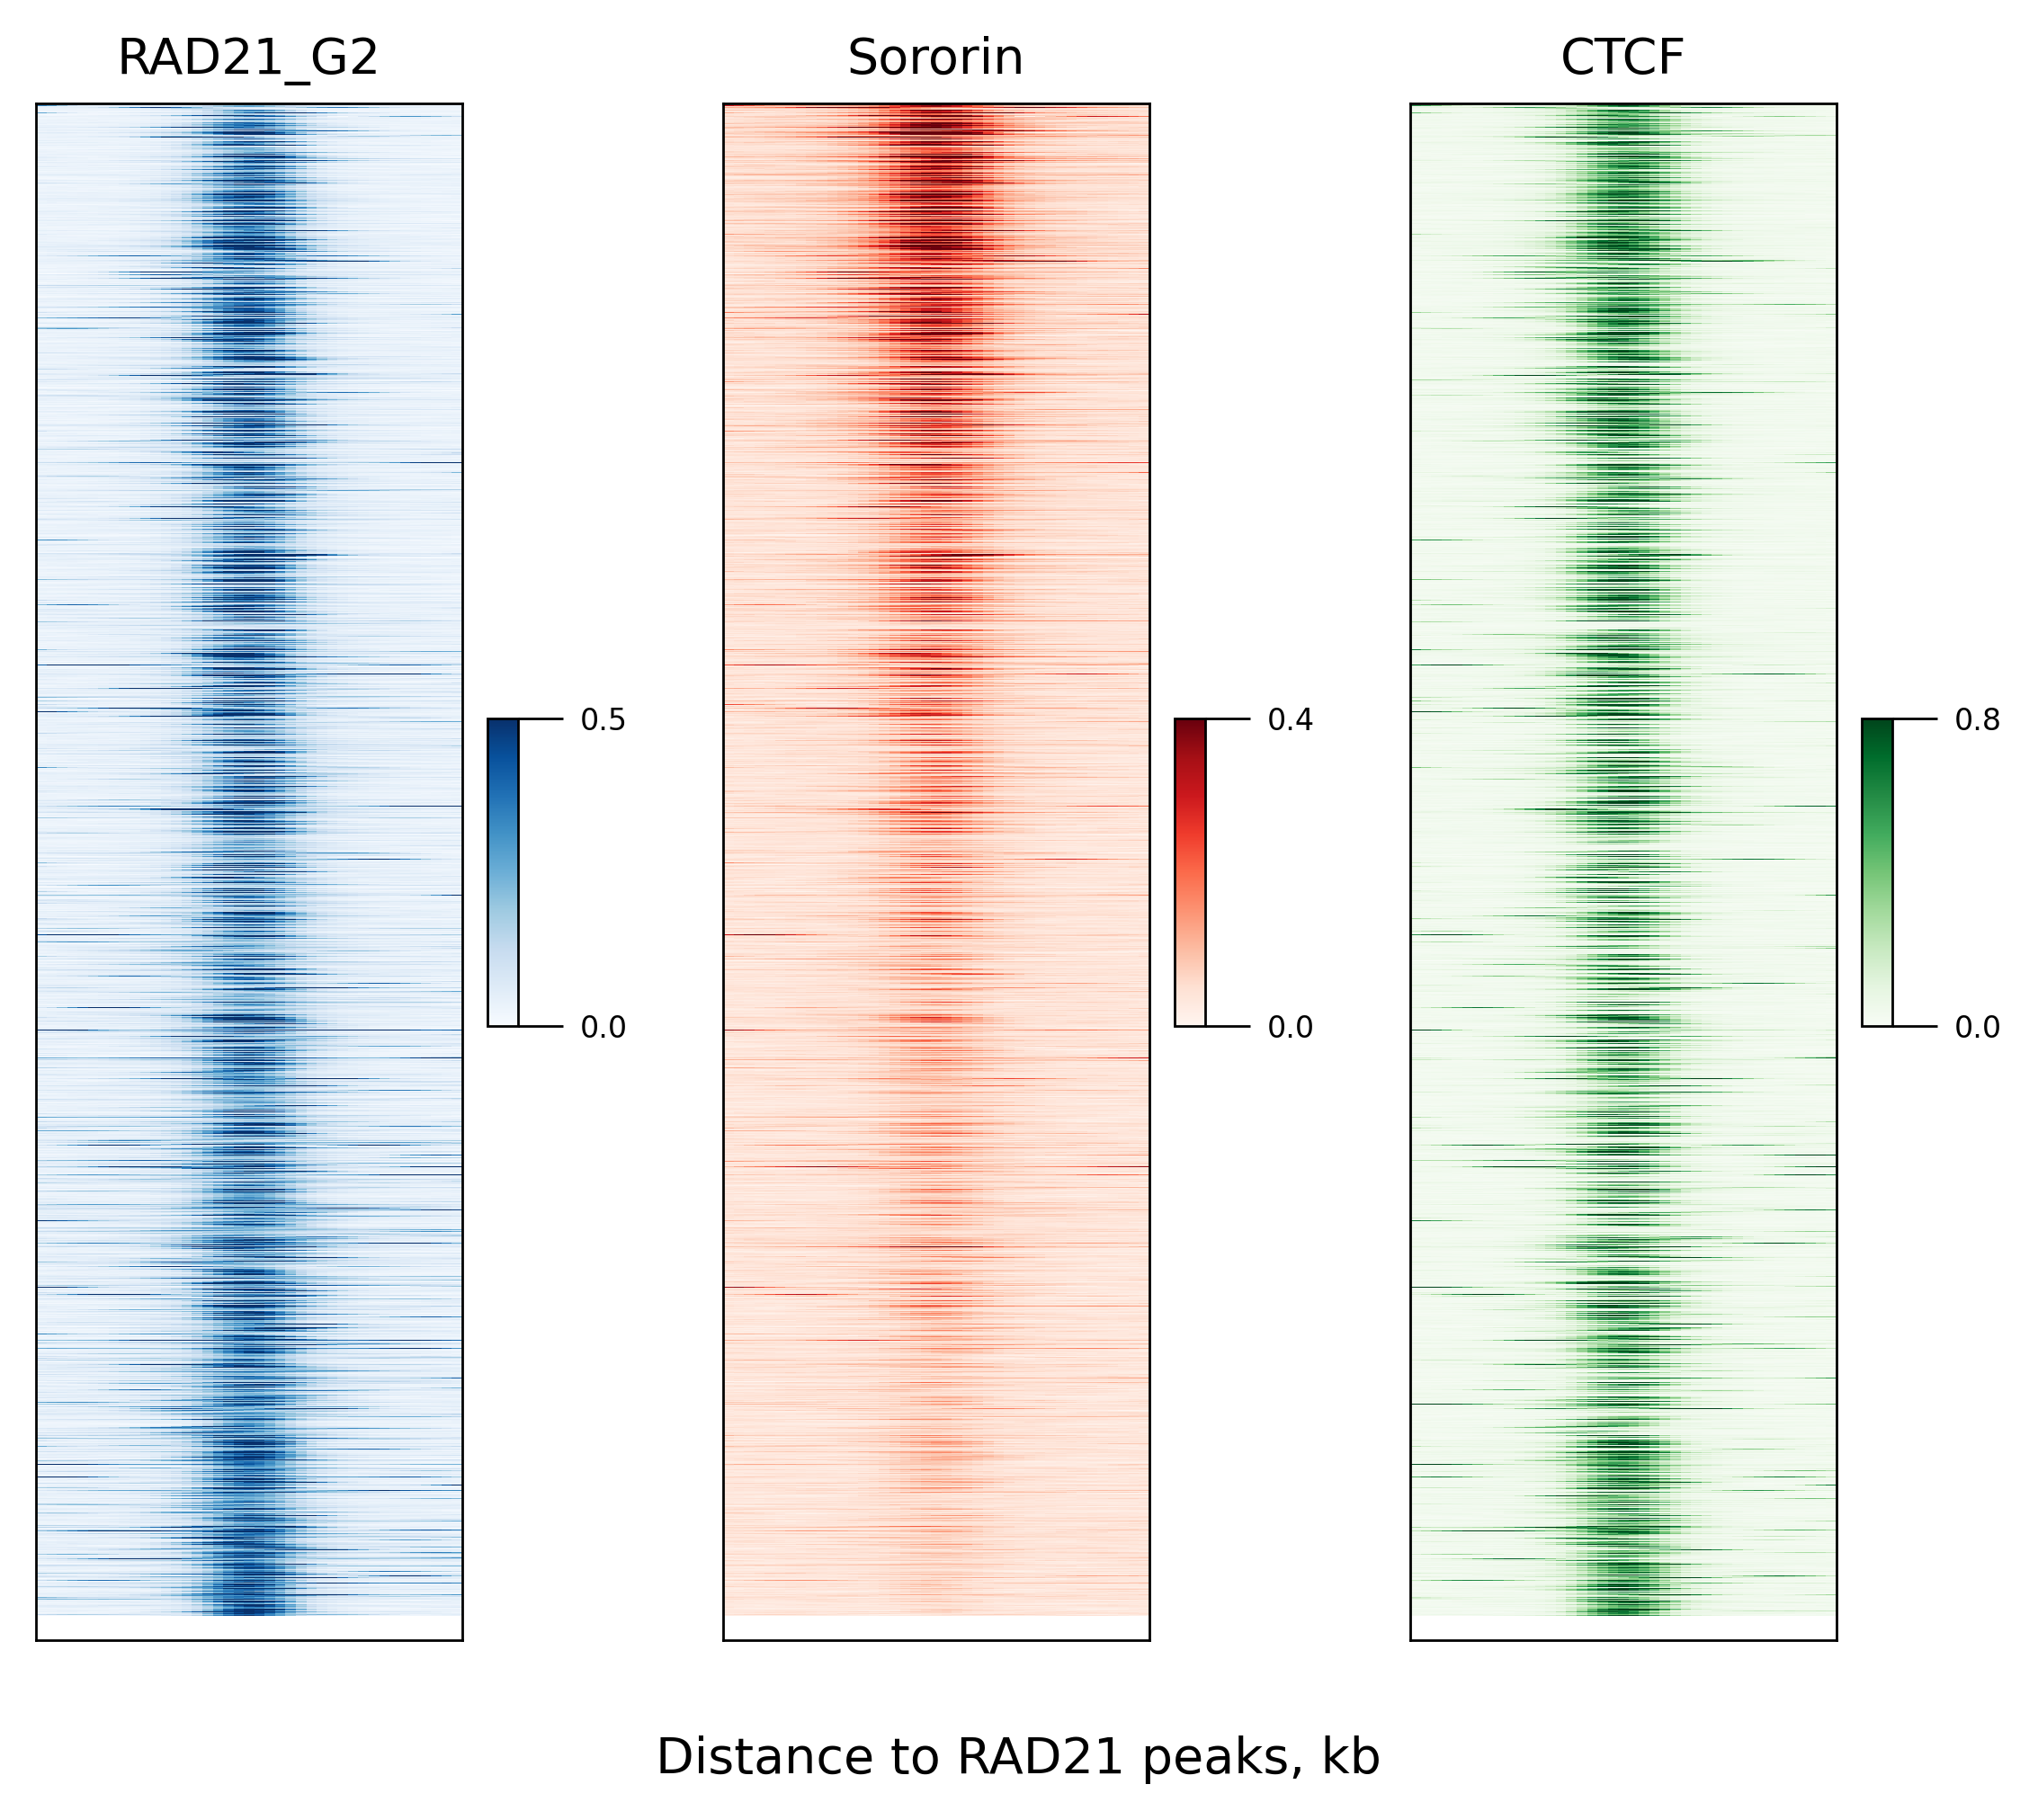

In [21]:
with sns.plotting_context('talk'):
    fig, axes = plt.subplots(1, 3, figsize=(6, 5), dpi=400)

    # Sort peaks by Sor/RAD21 ratio
    idx = rad21_peaks.sort_values('Sor_RAD21_CPM_ratio', ascending=False).index
        
    for col_idx, plot_protein in enumerate(('RAD21_G2', 'Sororin', 'CTCF')):
        plt.sca(axes[col_idx])
        hmap = heatmaps[plot_protein][idx, :]
        
        settings = protein_settings[plot_protein]
        
        g = plt.imshow(hmap, vmin=settings['vmin'], vmax=settings['vmax'], aspect='auto', cmap=settings['cmap'], interpolation='none')
        cbar = plt.colorbar(g, shrink=.2, fraction=.1, aspect=10)
        cbar.locator = plt.LinearLocator(2)
        cbar.ax.tick_params(labelsize=6, width=0.5)
        cbar.update_ticks()
        for spine in cbar.ax.spines.values():
            spine.set_linewidth(0.5)
        plt.gca().set_yticks([])
        plt.xticks([], [])
        #plt.xlim(80, 120)
        plt.title(f'{plot_protein}', fontsize=10)
    
    for ax in axes.flat:
    # Set border linewidth and make all spines visible
        for spine in ax.spines.values():
            spine.set_linewidth(0.5)  # Adjust linewidth as needed
            spine.set_visible(True)  # Ensure all borders are visible
    
    fig.text(0.5, -0.02, 'Distance to RAD21 peaks, kb', ha='center', fontsize=10)
    plt.tight_layout()